# AGME on the Brent Corpus

Trains AGME on child-directed English (BreissHayesBrent corpus) and
evaluates how well it discovers true morpheme boundaries versus accidental
suffix-like patterns.

**Reference:** Brent & Cartwright (1996) / BreissHayesBrent format.

## Corpus description

| File | Contents |
|------|----------|
| `data/words_train.txt` | Surface-form word tokens (Klattbet phonemes) |
| `data/words_gold.txt` | Gold segmentation: `\|` = true boundary, `+` = accidental |
| `data/words_ortho.txt` | English orthography for reference |

**Klattbet symbol reference (one char per phoneme):**

| Symbol | IPA | Example |
|--------|-----|---------|
| `@` | æ | th**a**t |
| `D` | ð | **th**e |
| `T` | θ | **th**ing |
| `I` | ɪ | k**i**tty |
| `E` | ɛ | g**e**t |
| `G` | ŋ | eati**ng** |
| `S` | ʃ | **sh**oe |
| `^` | ʌ | wh**a**t |
| `x` | ə | gon**na** |
| `R` | ɝ | g**ir**l |
| `C` | tʃ | **ch**ew |
| `J` | dʒ | **j**ust |
| `W` | aʊ | **ou**t |
| `Y` | aɪ | l**i**ke |
| `O` | ɔɪ | t**oy** |

## 1. Setup

In [3]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # find agme package

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from tqdm.auto import tqdm
matplotlib.rcParams["figure.figsize"] = (12, 5)
matplotlib.rcParams["font.size"] = 11

from agme import Model

# Evaluation helpers and Klattbet IPA map (in data/ directory)
sys.path.insert(0, "data")
from evaluate import load_corpus, evaluate_model, evaluate_suffix_types, gold_boundary_positions
from klattbet import KLATTBET_TO_IPA  # phoneme → IPA for panphon P-map prior

print("Imports OK.")

Imports OK.


## 2. Load corpus

In [4]:
# Load the prepared word-token corpus
surfaces = load_corpus("data/words_train.txt")
golds    = load_corpus("data/words_gold.txt")
orthos   = load_corpus("data/words_ortho.txt")

print(f"Loaded {len(surfaces)} word tokens")
print(f"Unique surface types: {len(set(surfaces))}")

# Summary of gold boundaries
n_true = sum(1 for g in golds if '|' in g)
n_acc  = sum(1 for g in golds if '+' in g)
n_mono = len(golds) - n_true - n_acc
print(f"\nGold boundary breakdown:")
print(f"  Monomorphemic:              {n_mono:6d} ({100*n_mono/len(golds):.1f}%)")
print(f"  With true boundary |:       {n_true:6d} ({100*n_true/len(golds):.1f}%)")
print(f"  With accidental match +:    {n_acc:6d}  ({100*n_acc/len(golds):.1f}%)")

# Show a sample
print("\nSample words (surface → gold):")
seen = set()
for surf, gold, orth in zip(surfaces, golds, orthos):
    if orth not in seen and ('|' in gold or '+' in gold):
        print(f"  {surf:15s} → {gold:15s}  ({orth})")
        seen.add(orth)
    if len(seen) >= 12:
        break

Loaded 85654 word tokens
Unique surface types: 500

Gold boundary breakdown:
  Monomorphemic:               73882 (86.3%)
  With true boundary |:         8517 (9.9%)
  With accidental match +:      3255  (3.8%)

Sample words (surface → gold):
  kIti            → kIt|i            (kitty)
  mcrgi           → mcrg|i           (Morgie)
  w^nts           → w^nt|s           (wants)
  Wt              → W+t              (out)
  w^ts            → w^t|s            (what's)
  itIG            → it|IG            (eating)
  D@ts            → D@t|s            (that's)
  mami            → mam|i            (Mommy)
  lEts            → lEt|s            (let's)
  duIG            → du|IG            (doing)
  hRt             → hR+t             (hurt)
  st@ndIG         → st@nd|IG         (standing)


## 3. Train AGME

**Training strategy:** We train on *type*-unique words (deduplicated) to keep
compute tractable, but weight each type by its token frequency so the PYP
receives the correct counts.

For a quick experiment (default): `N_TRAIN = 500` unique types, `N_SWEEPS = 100`.
For a full experiment: `N_TRAIN = None` (all types), `N_SWEEPS = 500`.

> **Timing estimates** (with `identity_only=True`, i.e. no phonological learning):
> 500 types × 100 sweeps ≈ 8–15 minutes on a laptop.
> Full corpus × 100 sweeps ≈ 40–90 minutes.
> With phonological grammar active (`identity_only=False`): ×5–10 slower.

In [20]:
# ---- Configuration ----
# Corpus selection:
#   "top_n"    — top N_TRAIN types by frequency from words_train.txt (default)
#   "paradigm" — the 200-type paradigm-rich subset (data/words_paradigm.txt),
#                which includes z/s/Iz alternation pairs (sak/saks, h@nd/h@ndz,
#                kIs/kIsIz, etc.).  Gold/ortho are still drawn from words_train.txt
#                for any types that overlap.
CORPUS     = "top_n"

N_TRAIN    = 200      # used when CORPUS="top_n"; None = all types
N_SWEEPS   = 100
BURN_IN    = 30
SEED       = 42
IDENTITY   = False     # False to enable full phonological grammar (much slower)

# --- PYP parameters ---
PYP_DISCOUNT      = 0.5   # d ∈ [0, 1): higher → weaker rich-get-richer, more UR types
PYP_CONCENTRATION = 1.0   # α > 0: higher → more new tables regardless of counts

# --- Phonological grammar ---
PRIOR_SCALE       = 2.25   # multiplied onto all constraint prior_weights (P-map targets);
                           # raises initial weights and the values regularisation contracts to
EPENTHESIS_PRIOR  = 1.0   # base prior (μ) for *MAP(∅,y): penalty for inserting a segment
DELETION_PRIOR    = 1.0   # base prior (μ) for *MAP(x,∅): penalty for deleting a segment
PRIOR_SIGMA       = 1.0   # fixed regularisation width σ; how tightly weights are pulled
                           # back toward their P-map targets after each MaxEnt update

# --- Inference ---
MAXENT_UPDATE_EVERY = 1  # run MaxEnt weight update every this many Gibbs sweeps
MAX_MORPHEME_LEN    = 8   # max characters in a single morpheme span (DP pruning)
TOP_K_URS           = 8   # UR candidates evaluated per (span, class) pair
# ---- End config ----

from collections import Counter
type_counts = Counter(surfaces)

if CORPUS == "paradigm":
    # Load the paradigm type set and filter the full corpus to those types,
    # preserving gold/ortho alignment.
    paradigm_types = set(
        w.strip() for w in open("data/words_paradigm.txt").read().splitlines() if w.strip()
    )
    top_types = paradigm_types
    print(f"Corpus: data/words_paradigm.txt ({len(top_types)} paradigm types)")
else:  # "top_n"
    if N_TRAIN is not None:
        top_types = {t for t, _ in type_counts.most_common(N_TRAIN)}
    else:
        top_types = set(surfaces)
    print(f"Corpus: data/words_train.txt (top {len(top_types)} types by frequency)")

filtered = [(s, g, o) for s, g, o in zip(surfaces, golds, orthos) if s in top_types]
train_surfaces = [x[0] for x in filtered]
train_golds    = [x[1] for x in filtered]

print(f"Training on {len(train_surfaces)} tokens ({len(set(train_surfaces))} unique types)")
print(f"Alphabet: {len(set(''.join(train_surfaces)))} phoneme symbols")

Corpus: data/words_train.txt (top 200 types by frequency)
Training on 73982 tokens (200 unique types)
Alphabet: 39 phoneme symbols


In [21]:
model = Model(
    morpheme_classes=["stem", "suffix"],
    identity_phonology=IDENTITY,
    pyp_discount=PYP_DISCOUNT,
    pyp_concentration=PYP_CONCENTRATION,
    prior_scale=PRIOR_SCALE,
    epenthesis_prior=EPENTHESIS_PRIOR,
    deletion_prior=DELETION_PRIOR,
    prior_sigma=PRIOR_SIGMA,
    # ipa_map only affects the P-map prior weights; ignored when identity_only=True
    ipa_map=None if IDENTITY else KLATTBET_TO_IPA,
)
model.fit(
    train_surfaces,
    n_sweeps=N_SWEEPS,
    burn_in=BURN_IN,
    maxent_update_every=MAXENT_UPDATE_EVERY,
    max_morpheme_len=MAX_MORPHEME_LEN,
    top_k_urs=TOP_K_URS,
    print_every=0,
    progress_bar=True,
    seed=SEED,
)
print("\nTraining complete.")

Training: 100%|██████████| 100/100 [04:07<00:00,  2.47s/sweep, phase=sampling, top_w=2.250, types=176]


Training complete.


## 4. Morpheme lexicon

In [22]:
lexicon = model.morphology.morpheme_lexicon()

for cls, counts in lexicon.items():
    total = sum(counts.values())
    print(f"\n--- {cls.upper()} (total tokens: {total}, types: {len(counts)}) ---")
    top = sorted(counts.items(), key=lambda x: -x[1])[:25]
    for ur, cnt in top:
        bar = "█" * int(30 * cnt / top[0][1])
        print(f"  {ur:18s}  {cnt:5d}  {bar}")


--- STEM (total tokens: 70867, types: 159) ---
  yu                   6306  ██████████████████████████████
  I                    3143  ██████████████
  D^                   2735  █████████████
  D@t                  2459  ███████████
  hi                   1934  █████████
  w^                   1640  ███████
  no                   1633  ███████
  e                    1608  ███████
  De                   1501  ███████
  tu                   1494  ███████
  yU                   1343  ██████
  go                   1261  █████
  an                   1171  █████
  o                    1078  █████
  @nd                  1025  ████
  w^n                   996  ████
  wi                    986  ████
  oke                   927  ████
  k@n                   912  ████
  k^m                   888  ████
  In                    883  ████
  gEt                   880  ████
  m                     814  ███
  yR                    804  ███
  DI                    802  ███

--- SUFFIX (total tokens: 2

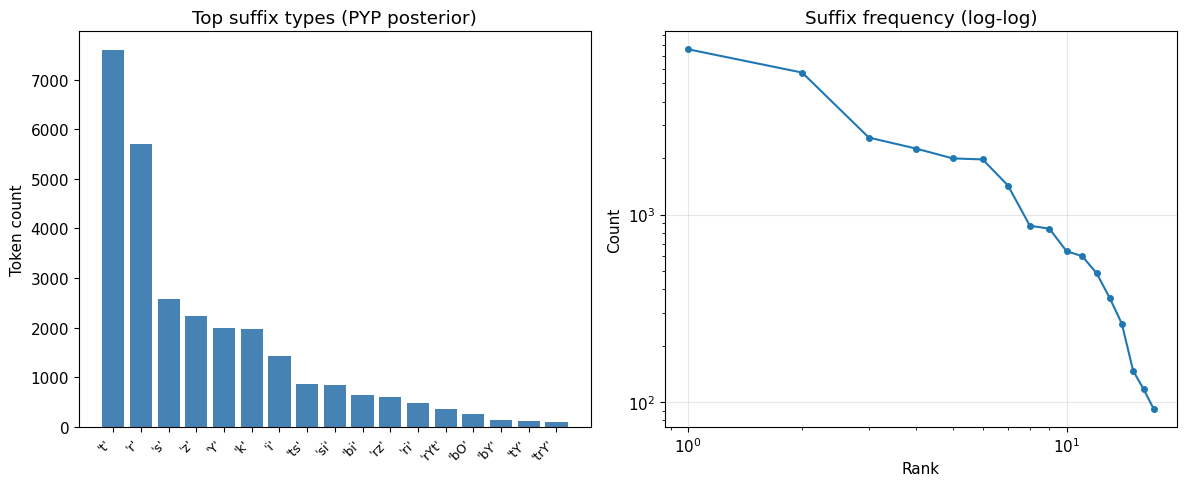

In [23]:
# Frequency distribution of suffix types (log-log expected Zipf shape)
suffix_counts = lexicon.get("suffix", {})
if suffix_counts:
    sorted_counts = sorted(suffix_counts.values(), reverse=True)
    fig, (ax1, ax2) = plt.subplots(1, 2)

    # Bar chart of top suffixes
    top_n = min(20, len(suffix_counts))
    top_items = sorted(suffix_counts.items(), key=lambda x: -x[1])[:top_n]
    labels = [repr(ur) for ur, _ in top_items]
    vals = [cnt for _, cnt in top_items]
    ax1.bar(range(top_n), vals, color="steelblue")
    ax1.set_xticks(range(top_n))
    ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax1.set_title("Top suffix types (PYP posterior)")
    ax1.set_ylabel("Token count")

    # Rank-frequency log-log
    ax2.loglog(range(1, len(sorted_counts)+1), sorted_counts, "o-", ms=4)
    ax2.set_xlabel("Rank")
    ax2.set_ylabel("Count")
    ax2.set_title("Suffix frequency (log-log)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. Boundary evaluation

In [10]:
from evaluate import evaluate_model, EvalResult

result = evaluate_model(model, train_surfaces, train_golds, verbose=False, progress_bar=True)
print(result)

Evaluating:   3%|▎         | 2161/63236 [00:16<07:36, 133.93word/s]


KeyboardInterrupt: 

NameError: name 'result' is not defined

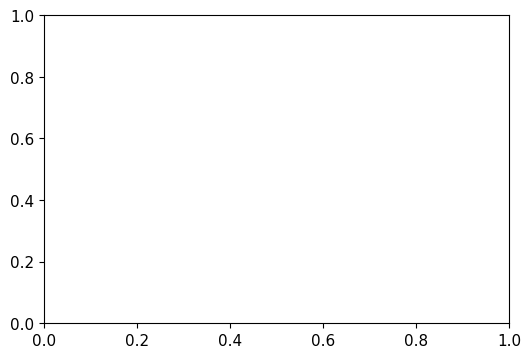

In [24]:
# Visualise TP/FP/FN breakdown
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["TP (correct)", "FP at +\n(accidental)", "FP other", "FN (missed)"]
vals   = [result.tp, result.fp_acc, result.fp_true, result.fn]
colors = ["#2ecc71", "#e67e22", "#e74c3c", "#3498db"]
bars   = ax.bar(labels, vals, color=colors)
ax.bar_label(bars, padding=3)
ax.set_title(f"Boundary classification  (P={result.precision:.2f}, R={result.recall:.2f}, F1={result.f1:.2f})")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Suffix-type evaluation

In [25]:
from evaluate import evaluate_suffix_types

se = evaluate_suffix_types(model, train_golds, train_surfaces)

print(f"=== Suffix-type evaluation ===")
print(f"Gold suffix types ({len(se.true_suffix_types)}):")
for sf, cnt in sorted(se.true_suffix_types.items(), key=lambda x: -x[1])[:15]:
    mark = "✓" if sf in se.tp_types else "✗"
    print(f"  {mark} {sf:12s}  count={cnt}")

print(f"\nModel found {len(se.found_suffix_types)} suffix types:")
for sf, cnt in sorted(se.found_suffix_types.items(), key=lambda x: -x[1])[:15]:
    mark = "✓" if sf in se.tp_types else "✗"
    print(f"  {mark} {sf:12s}  count={cnt}")

type_p = len(se.tp_types) / len(se.found_suffix_types) if se.found_suffix_types else 0
type_r = len(se.tp_types) / len(se.true_suffix_types) if se.true_suffix_types else 0
type_f1 = 2*type_p*type_r/(type_p+type_r) if (type_p+type_r) > 0 else 0
print(f"\nType-level:  P={type_p:.2f}  R={type_r:.2f}  F1={type_f1:.2f}")

=== Suffix-type evaluation ===
Gold suffix types (6):
  ✓ s             count=2005
  ✓ i             count=1441
  ✓ z             count=1102
  ✗ nt            count=1039
  ✗ IG            count=834
  ✗ li            count=76

Model found 17 suffix types:
  ✗ t             count=7593
  ✗ r             count=5707
  ✓ s             count=2572
  ✓ z             count=2247
  ✗ Y             count=1992
  ✗ k             count=1967
  ✓ i             count=1428
  ✗ ts            count=871
  ✗ si            count=842
  ✗ bi            count=638
  ✗ rz            count=600
  ✗ ri            count=488
  ✗ rYt           count=360
  ✗ bO            count=262
  ✗ bY            count=147

Type-level:  P=0.18  R=0.50  F1=0.26


## 7. Phonological weights (if grammar active)

In [26]:
if not model._identity_phonology:
    fw = model.phonology.faithfulness_weights()
    sorted_fw = sorted(fw.items(), key=lambda kv: -abs(kv[1]["deviation"]))

    print(f"Top 20 constraints by deviation from P-map prior:")
    print(f"{'Constraint':<25} {'weight':>8} {'prior':>8} {'deviation':>10}")
    print("-" * 55)
    for cr, vals in sorted_fw[:20]:
        dev = vals["deviation"]
        print(f"  {cr:<23} {vals['weight']:>8.3f} {vals['prior']:>8.3f} {dev:>10.3f}")
else:
    print("(Phonological grammar is identity_only — no weights to show)")
    print("Set IDENTITY=False in cell 3 and retrain for phonological analysis.")

Top 20 constraints by deviation from P-map prior:
Constraint                  weight    prior  deviation
-------------------------------------------------------
  *MAP(c,o)                  0.094    0.094      0.000
  *MAP(∅,@)                  2.250    2.250     -0.000
  *MAP(@,∅)                  2.250    2.250     -0.000
  *MAP(∅,C)                  2.250    2.250     -0.000
  *MAP(∅,D)                  2.250    2.250     -0.000
  *MAP(D,∅)                  2.250    2.250     -0.000
  *MAP(∅,E)                  2.250    2.250     -0.000
  *MAP(∅,G)                  2.250    2.250     -0.000
  *MAP(G,∅)                  2.250    2.250     -0.000
  *MAP(∅,I)                  2.250    2.250     -0.000
  *MAP(I,∅)                  2.250    2.250     -0.000
  *MAP(∅,J)                  2.250    2.250     -0.000
  *MAP(∅,O)                  2.250    2.250     -0.000
  *MAP(∅,R)                  2.250    2.250     -0.000
  *MAP(∅,S)                  2.250    2.250     -0.000
  *MAP(∅,T)   

## 8. Browse individual parses

In [27]:
# Inspect parses for specific words — change these to explore
WORDS_TO_INSPECT = ["kIti", "w^nts", "itIG", "D@ts", "mami", "duIG"]

for word in WORDS_TO_INSPECT:
    if word not in surfaces:
        print(f"[{word}] not in training set")
        continue
    idx = surfaces.index(word)
    gold = golds[idx]
    orth = orthos[idx]

    parse = model.parse(word)
    pred = "|".join(parse.morphemes)
    morphs = " + ".join(f"{cls}:/{ur}/" for cls, ur in zip(parse.morpheme_classes, parse.morphemes))

    print(f"[{word}] ({orth})")
    print(f"  Gold:      {gold}")
    print(f"  Predicted: {pred}  →  {morphs}")
    print(f"  logP = {parse.log_prob:.3f}")
    print()

[kIti] (kitty)
  Gold:      kIt|i
  Predicted: k^m|t  →  stem:/k^m/ + suffix:/t/
  logP = -7.635

[w^nts] (wants)
  Gold:      w^nt|s
  Predicted: D@t|z  →  stem:/D@t/ + suffix:/z/
  logP = -9.780

[itIG] (eating)
  Gold:      it|IG
  Predicted: o|si  →  stem:/o/ + suffix:/si/
  logP = -10.012

[D@ts] (that's)
  Gold:      D@t|s
  Predicted: D@t|Y  →  stem:/D@t/ + suffix:/Y/
  logP = -6.333

[mami] (Mommy)
  Gold:      mam|i
  Predicted: mamx  →  stem:/mamx/
  logP = -3.093

[duIG] (doing)
  Gold:      du|IG
  Predicted: goIG  →  stem:/goIG/
  logP = -3.514

